# Gap Control From Mock NHL Tracking Data

Gap control is a simple way to ask: when one team is near the puck, how close is the nearest defender? This notebook uses the mock CSV instead of hard-coded sample rows so the same workflow can grow when better data becomes available.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

tracking = pd.read_csv('trackingData_expanded.csv')

numeric_cols = ['Location.X', 'Location.Y', 'velocity_x', 'velocity_y', 'UTCTime']
for col in numeric_cols:
    tracking[col] = (
        tracking[col]
        .astype(str)
        .str.replace('−', '-', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

running = tracking[tracking['ClockState'] == 'ClockStateRunning'].copy()
players = running[running['entityType'] == 'player'].copy()
puck = running[running['entityType'] == 'puck'].copy()

print('Running timestamps:', sorted(running['timeStamp'].unique()))
print('Teams:', sorted(players['team'].dropna().unique()))
display(players)

Running timestamps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
Teams: ['Edmonton', 'Toronto']


,timeStamp,entityType,player,team,Location.X,Location.Y,velocity_x,velocity_y,UTCTime,ClockState,OnPlayingSurface
0,1,player,Matthews,Toronto,60,40,1.5000,0.3000,1000,ClockStateRunning,True
1,1,player,Marner,Toronto,55,35,1.2000,-0.2000,1000,ClockStateRunning,True
2,1,player,Nylander,Toronto,65,38,0.8000,0.5000,1000,ClockStateRunning,True
3,1,player,Rielly,Toronto,30,50,0.3000,-0.2000,1000,ClockStateRunning,True
4,1,player,Brodie,Toronto,25,45,-0.1000,0.1000,1000,ClockStateRunning,True
...,...,...,...,...,...,...,...,...,...,...,...
189,15,player,Draisaitl,Edmonton,34,53,-1.6000,-0.3000,15000,ClockStateRunning,True
190,15,player,Bouchard,Edmonton,31,59,-1.4000,-0.1000,15000,ClockStateRunning,True
191,15,player,Nurse,Edmonton,36,51,-1.1000,-0.2000,15000,ClockStateRunning,True
192,15,player,Ekholm,Edmonton,40,49,-1.0000,-0.3000,15000,ClockStateRunning,True


## Calculate Gap Control

For each running timestamp, the notebook identifies the player closest to the puck as the estimated puck carrier. Then it finds the closest opponent to that puck carrier. The distance between those two players is the gap.

In [30]:
def distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

gap_rows = []

for timestamp, frame_players in players.groupby('timeStamp'):
    puck_row = puck[puck['timeStamp'] == timestamp]
    if puck_row.empty:
        continue

    puck_x = puck_row.iloc[0]['Location.X']
    puck_y = puck_row.iloc[0]['Location.Y']

    frame_players = frame_players.copy()
    frame_players['distance_to_puck'] = distance(
        frame_players['Location.X'], frame_players['Location.Y'], puck_x, puck_y
    )

    carrier = frame_players.sort_values('distance_to_puck').iloc[0]
    opponents = frame_players[frame_players['team'] != carrier['team']].copy()
    opponents['gap_distance'] = distance(
        opponents['Location.X'], opponents['Location.Y'], carrier['Location.X'], carrier['Location.Y']
    )

    closest_opponent = opponents.sort_values('gap_distance').iloc[0]

    gap_rows.append({
        'timeStamp': timestamp,
        'puck_x': puck_x,
        'puck_y': puck_y,
        'carrier_team': carrier['team'],
        'carrier_player': carrier['player'],
        'carrier_distance_to_puck': carrier['distance_to_puck'],
        'closest_opponent': closest_opponent['player'],
        'opponent_team': closest_opponent['team'],
        'gap_distance': closest_opponent['gap_distance']
    })

gap_control_df = pd.DataFrame(gap_rows)
gap_control_df['pressure_label'] = pd.cut(
    gap_control_df['gap_distance'],
    bins=[-np.inf, 6.0, 11.0, np.inf],
    labels=['tight pressure', 'medium gap', 'loose gap']
)

display(gap_control_df)

,timeStamp,puck_x,puck_y,carrier_team,carrier_player,carrier_distance_to_puck,closest_opponent,opponent_team,gap_distance,pressure_label
0,1,62,41,Toronto,Matthews,2.2361,Hyman,Edmonton,15.1327,loose gap
1,2,64,41,Toronto,Matthews,3.1623,Hyman,Edmonton,17.2627,loose gap
2,3,65,41,Toronto,Nylander,2.8284,Hyman,Edmonton,24.5153,loose gap
3,4,64,40,Toronto,Tavares,2.2361,Hyman,Edmonton,13.0000,loose gap
4,5,62,40,Toronto,Tavares,3.0000,Hyman,Edmonton,10.1980,medium gap
5,6,60,40,Toronto,Tavares,4.1231,McDavid,Edmonton,7.2111,medium gap
6,7,57,40,Edmonton,McDavid,1.4142,Tavares,Toronto,6.3246,medium gap
7,8,54,40,Edmonton,Ekholm,2.8284,Tavares,Toronto,5.0000,tight pressure
8,9,51,40,Edmonton,Nurse,4.2426,Tavares,Toronto,5.6569,tight pressure
9,10,30,40,Toronto,Tavares,5.0000,Ekholm,Edmonton,8.5440,medium gap


## Gap Control Summary

These outputs are deliberately small: average gap by team, pressure counts, and simple descriptive stats.

In [31]:
gap_summary = gap_control_df['gap_distance'].describe().to_frame('gap_distance')
team_gap_summary = (
    gap_control_df.groupby('carrier_team', as_index=False)
    .agg(
        possessions_estimated=('timeStamp', 'count'),
        average_gap=('gap_distance', 'mean'),
        smallest_gap=('gap_distance', 'min'),
        largest_gap=('gap_distance', 'max')
    )
    .sort_values('average_gap')
)
pressure_counts = gap_control_df['pressure_label'].value_counts().rename_axis('pressure_label').reset_index(name='timestamps')

display(gap_summary)
display(team_gap_summary.sort_values('possessions_estimated', ascending=False))
display(pressure_counts)

,gap_distance
count,15.0000
mean,10.4549
std,5.4995
min,3.6056
25%,6.7678
50%,8.5440
75%,12.9031
max,24.5153


,carrier_team,possessions_estimated,average_gap,smallest_gap,largest_gap
1,Toronto,12,11.6535,3.6056,24.5153
0,Edmonton,3,5.6605,5.0000,6.3246


,pressure_label,timestamps
0,medium gap,6
1,loose gap,6
2,tight pressure,3


## Quick Visual Outputs

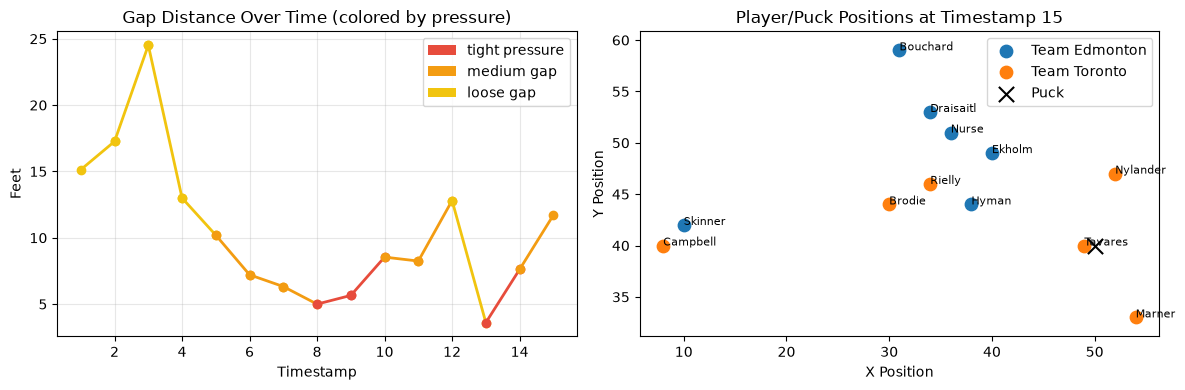

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Color map for pressure labels
pressure_colors = {
    'tight pressure': '#e74c3c',    # red
    'medium gap': '#f39c12',         # orange
    'loose gap': '#f1c40f'           # yellow
}

# Gap Distance Over Time with colored segments
gap_sorted = gap_control_df.sort_values('timeStamp')
for i in range(len(gap_sorted) - 1):
    curr = gap_sorted.iloc[i]
    next_row = gap_sorted.iloc[i + 1]
    color = pressure_colors.get(curr['pressure_label'], '#95a5a6')
    axes[0].plot([curr['timeStamp'], next_row['timeStamp']], 
                 [curr['gap_distance'], next_row['gap_distance']], 
                 color=color, linewidth=2, marker='o', markersize=6)

axes[0].set_title('Gap Distance Over Time (colored by pressure)')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Feet')
axes[0].grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=pressure_colors[label], label=label) 
                   for label in ['tight pressure', 'medium gap', 'loose gap']]
axes[0].legend(handles=legend_elements, loc='best')

latest_timestamp = gap_control_df['timeStamp'].max()
snapshot_players = players[players['timeStamp'] == latest_timestamp]
snapshot_puck = puck[puck['timeStamp'] == latest_timestamp].iloc[0]

for team, team_players in snapshot_players.groupby('team'):
    axes[1].scatter(team_players['Location.X'], team_players['Location.Y'], label=f'Team {team}', s=80)
    for _, row in team_players.iterrows():
        axes[1].annotate(row['player'], (row['Location.X'], row['Location.Y']), fontsize=8)

axes[1].scatter(snapshot_puck['Location.X'], snapshot_puck['Location.Y'], label='Puck', s=120, marker='x', color='black')
axes[1].set_title(f'Player/Puck Positions at Timestamp {latest_timestamp}')
axes[1].set_xlabel('X Position')
axes[1].set_ylabel('Y Position')
axes[1].legend()
axes[1].axis('equal')

plt.tight_layout()
plt.show()